# 🧱 Part 09: Training and Loss: How Prediction Becomes Learning

> **Previous context**: Earlier parts built model components. Now we need to make parameters improve from data.
> **Goal for this part**: Hand-calculate Cross-Entropy, build a training loop, and inspect loss, gradients, batching, and accumulation.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why loss exists

A model outputs logits, not a lesson learned. Loss turns 'how wrong was the prediction?' into a number that gradient descent can reduce.

## 1. Cross-Entropy by hand

Softmax turns logits into probabilities. Cross-Entropy punishes the model when it gives low probability to the correct token.

## 2. Training loop

A basic loop does forward pass, loss calculation, backward pass, optimizer step, and metric logging.

## 3. Practical details

Batching, gradient accumulation, learning rate, and data quality all shape whether training is stable and useful.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] Cross-Entropy rewards high probability on the correct next token.
- [ ] Backpropagation computes gradients.
- [ ] The optimizer updates parameters to reduce loss over many batches.

Next, continue through the code cells for the Training Systems part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

### Loss
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.           [0,   1,  2,  3,  4]

          ┌─────────────────────────────────┐
Read the values printed above and connect them to the concept in this cell.          │  [0]  │ [1]  │ [2]  │ [3]  │
          └─────────────────────────────────┘
↓ Model forward          ┌─────────────────────────────────┐
Read the values printed above and connect them to the concept in this cell.          │  [0]   │ [1]  │ [2]  │ [3]  │
          └─────────────────────────────────┘
Read the values printed above and connect them to the concept in this cell.          ┌─────────────────────────────────┐
Read the values printed above and connect them to the concept in this cell.          │  [1]   │ [2]  │ [3]  │ [4]  │
          └─────────────────────────────────┘

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [2]:
# Teaching note: follow this line to see the main step.
sentence = torch.tensor([0, 1, 2, 3, 4])  # Teaching note: follow this line to see the main step.

print('Read the values printed above and connect them to the concept in this cell.', sentence.tolist())
print()

# Teaching note: follow this line to see the main step.
input_ids = sentence[:-1]  # [0, 1, 2, 3]
print('Read the values printed above and connect them to the concept in this cell.', input_ids.tolist())
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
target_ids = sentence[1:]   # [1, 2, 3, 4]
print('Read the values printed above and connect them to the concept in this cell.', target_ids.tolist())
print('Read the values printed above and connect them to the concept in this cell.')
print()

print('Read the values printed above and connect them to the concept in this cell.')
for i in range(len(input_ids)):
    print(f"Read the values printed above and connect them to the concept in this cell.{i}Read the values printed above and connect them to the concept in this cell.{', '.join(str(x) for x in input_ids[:i+1].tolist())}Read the values printed above and connect them to the concept in this cell.{target_ids[i].item()}")

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### Loss
Read the values printed above and connect them to the concept in this cell.
Loss
```
Read the values printed above and connect them to the concept in this cell.1. Read the values printed above and connect them to the concept in this cell.2. Read the values printed above and connect them to the concept in this cell.3. Read the values printed above and connect them to the concept in this cell.4. Read the values printed above and connect them to the concept in this cell.```

LossLoss
Read the values printed above and connect them to the concept in this cell.

In [3]:
# Teaching note: follow this line to see the main step.
vocab_size = 5
seq_len = 4  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
torch.manual_seed(123)
logits = torch.randn(1, seq_len, vocab_size)  # [batch=1, seq_len=4, vocab=5]
targets = torch.tensor([[1, 2, 3, 4]])          # [batch=1, seq_len=4]

print(f"Read the values printed above and connect them to the concept in this cell.{logits.shape}")
print(f"Read the values printed above and connect them to the concept in this cell.{targets.shape}")
print()

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.{logits[0, 0].tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{targets[0, 0].item()}")
print(f"Read the values printed above and connect them to the concept in this cell.{targets[0, 0].item()}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [4]:
# Teaching note: follow this line to see the main step.
print('Loss')
print()

total_loss = 0.0
for pos in range(seq_len):
    # Teaching note: follow this line to see the main step.
    pos_logits = logits[0, pos]  # [vocab_size]
    # Teaching note: follow this line to see the main step.
    correct_id = targets[0, pos].item()
    
    # Teaching note: follow this line to see the main step.
    probs = F.softmax(pos_logits, dim=-1)
    
    # Teaching note: follow this line to see the main step.
    correct_prob = probs[correct_id].item()
    
    # Teaching note: follow this line to see the main step.
    pos_loss = -math.log(correct_prob)
    total_loss += pos_loss
    
    print(f"Read the values printed above and connect them to the concept in this cell.{pos}Read the values printed above and connect them to the concept in this cell.{correct_id}, probability={correct_prob:.4f}, loss={pos_loss:.4f}")

# Teaching note: follow this line to see the main step.
manual_loss = total_loss / seq_len
print(f"Loss{manual_loss:.4f}")

# Teaching note: follow this line to see the main step.
pt_loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),  # [batch*seq_len, vocab]
    targets.reshape(-1)               # [batch*seq_len]
).item()
print(f"PyTorch cross_entropy: {pt_loss:.4f}")
print(f"Read the values printed above and connect them to the concept in this cell.{'[ok]' if abs(manual_loss - pt_loss) < 1e-4 else '[x]'}")

Loss
LossLossLossLoss
LossPyTorch cross_entropy: 1.6049
Read the values printed above and connect them to the concept in this cell.

In [5]:
# Teaching note: follow this line to see the main step.
PAD_ID = 0  # Teaching note: follow this line to see the main step.

batch_input = torch.tensor([
    [0, 1, 2, 3, 4, 0, 0],  # Teaching note: follow this line to see the main step.
    [0, 2, 4, 0, 0, 0, 0],  # Teaching note: follow this line to see the main step.
])

# Teaching note: follow this line to see the main step.
batch_target = torch.tensor([
    [1, 2, 3, 4, 0, 0, 0],  # Teaching note: follow this line to see the main step.
    [2, 4, 0, 0, 0, 0, 0],  # Teaching note: follow this line to see the main step.
])

print('"Batch Input:"')
print(batch_input)
print()
print('Read the values printed above and connect them to the concept in this cell.')
print(batch_target)
print()

# Teaching note: follow this line to see the main step.
batch_logits = torch.randn(2, 7, 5)  # [batch=2, seq=7, vocab=5]

# Teaching note: follow this line to see the main step.
loss_with_ignore = F.cross_entropy(
    batch_logits.reshape(-1, 5),       # [14, 5]
    batch_target.reshape(-1),           # [14]
    ignore_index=PAD_ID
)

loss_without_ignore = F.cross_entropy(
    batch_logits.reshape(-1, 5),
    batch_target.reshape(-1)
)

print(f"Loss{loss_with_ignore.item():.4f}")
print(f"Loss{loss_without_ignore.item():.4f}")
print(f"Loss")

Batch Input:tensor([[0, 1, 2, 3, 4, 0, 0],
        [0, 2, 4, 0, 0, 0, 0]])

Read the values printed above and connect them to the concept in this cell.tensor([[1, 2, 3, 4, 0, 0, 0],
        [2, 4, 0, 0, 0, 0, 0]])

LossLoss
Loss

In [6]:
# Teaching note: follow this line to see the main step.
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
        
        # Teaching note: follow this line to see the main step.
        self.attn1 = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn1 = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Linear(4*d_model, d_model)
        )
        self.norm1a = nn.LayerNorm(d_model)
        self.norm1f = nn.LayerNorm(d_model)
        
        self.attn2 = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn2 = nn.Sequential(
            nn.Linear(d_model, 4*d_model), nn.ReLU(), nn.Linear(4*d_model, d_model)
        )
        self.norm2a = nn.LayerNorm(d_model)
        self.norm2f = nn.LayerNorm(d_model)
        
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        batch_size, seq_len = x.shape
        x = self.token_emb(x) + self.pe[:seq_len, :]
        
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        
        # Block 1
        attn_out, _ = self.attn1(x, x, x, attn_mask=mask)
        x = self.norm1a(x + attn_out)
        x = self.norm1f(x + self.ffn1(x))
        
        # Block 2
        attn_out, _ = self.attn2(x, x, x, attn_mask=mask)
        x = self.norm2a(x + attn_out)
        x = self.norm2f(x + self.ffn2(x))
        
        x = self.ln_final(x)
        return self.lm_head(x)

print('"MiniGPT ModelDefinition complete！"')

MiniGPT ModelDefinition complete!

In [7]:
# Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
VOCAB_SIZE = 20
PAD_ID = 0
SEQ_LEN = 16
BATCH_SIZE = 8

# Teaching note: follow this line to see the main step.
train_data = torch.randint(1, VOCAB_SIZE, (100, SEQ_LEN))  # Teaching note: follow this line to see the main step.
print(f"trainingdata: {train_data.shape}Read the values printed above and connect them to the concept in this cell.{SEQ_LEN}Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in model.parameters()):,}")

Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.

In [8]:
# Teaching note: follow this line to see the main step.
NUM_EPOCHS = 5
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    num_batches = 0
    
    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i:i+BATCH_SIZE]  # [batch_size, seq_len]
        
        # Teaching note: follow this line to see the main step.
        input_ids = batch[:, :-1]      # Teaching note: follow this line to see the main step.
        target_ids = batch[:, 1:]       # Teaching note: follow this line to see the main step.
        
        # Forward
        logits = model(input_ids)  # [batch, seq_len-1, vocab_size]
        
        # Teaching note: follow this line to see the main step.
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),  # [batch*(seq_len-1), vocab_size]
            target_ids.reshape(-1)            # [batch*(seq_len-1)]
        )
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print(f"Loss{losses[0]:.4f}Read the values printed above and connect them to the concept in this cell.{losses[-1]:.4f}Read the values printed above and connect them to the concept in this cell.")

Epoch 1/5 | Loss: 3.0834
Epoch 2/5 | Loss: 2.9192
Epoch 3/5 | Loss: 2.8793
Epoch 4/5 | Loss: 2.8393
Epoch 5/5 | Loss: 2.7892

Loss

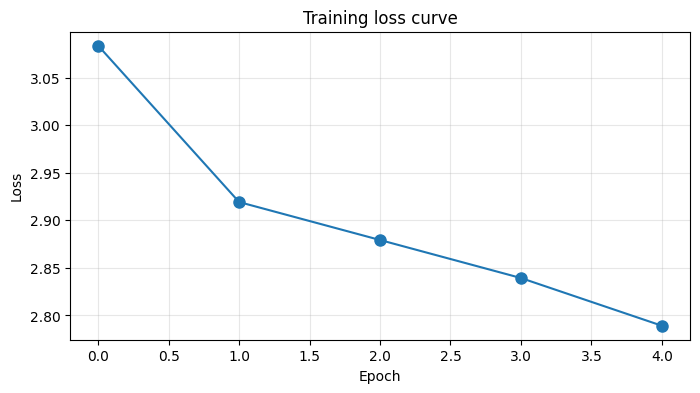

Loss

In [9]:
# Teaching note: follow this line to see the main step.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses, 'o-', markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss curve')
plt.grid(True, alpha=0.3)
plt.show()

print('Loss')


### Loss
Loss
```
LossRead the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.```

Read the values printed above and connect them to the concept in this cell.

#### Loss
Loss> Loss
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
```
Read the values printed above and connect them to the concept in this cell.                              ↓
                          loss = (y - target)²
```

Read the values printed above and connect them to the concept in this cell.```
∂loss/∂w = ∂loss/∂y × ∂y/∂w
         = 2(y - target) × x
```

Read the values printed above and connect them to the concept in this cell.Loss

In [10]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
w = torch.tensor([0.5], requires_grad=True)
b = torch.tensor([0.1], requires_grad=True)

x = torch.tensor([2.0])   # Teaching note: follow this line to see the main step.
target = torch.tensor([3.0])  # Teaching note: follow this line to see the main step.

print(f"Read the values printed above and connect them to the concept in this cell.{w.item():.2f}, b={b.item():.2f}")
print(f"Input x={x.item():.2f}Read the values printed above and connect them to the concept in this cell.{target.item():.2f}")
print()

# Forward
y = w * x + b              # y = 0.5*2 + 0.1 = 1.1
loss = (y - target) ** 2   # loss = (1.1 - 3)^2 = 3.61

print(f"Forward: y = w*x + b = {w.item()}*{x.item()} + {b.item()} = {y.item():.2f}")
print(f"Loss = (y - target)² = ({y.item():.2f} - {target.item():.2f})² = {loss.item():.2f}")
print()

# Backward
loss.backward()

print(f"∂loss/∂w = {w.grad.item():.4f}Loss{w.grad.item():.4f})")
print(f"∂loss/∂b = {b.grad.item():.4f}Loss{b.grad.item():.4f})")
print()

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print(f"∂loss/∂y = 2*(y - target) = 2*({y.item():.2f} - {target.item():.2f}) = {2*(y.item()-target.item()):.2f}")
print(f"∂y/∂w = x = {x.item():.2f}")
print(f"∂y/∂b = 1")
print(f"∂loss/∂w = ∂loss/∂y * ∂y/∂w = {2*(y.item()-target.item()):.2f} * {x.item():.2f} = {2*(y.item()-target.item())*x.item():.2f}")
print(f"Loss{w.grad.item():.4f}Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Forward: y = w*x + b = 0.5*2.0 + 0.10000000149011612 = 1.10
Loss = (y - target)² = (1.10 - 3.00)² = 3.61

LossLoss
Read the values printed above and connect them to the concept in this cell.∂loss/∂y = 2*(y - target) = 2*(1.10 - 3.00) = -3.80
∂y/∂w = x = 2.00
∂y/∂b = 1
∂loss/∂w = ∂loss/∂y * ∂y/∂w = -3.80 * 2.00 = -7.60
Loss

In [11]:
# Teaching note: follow this line to see the main step.
VOCAB_SIZE = 20
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

dummy_input = torch.randint(1, VOCAB_SIZE, (2, 16))   # [batch=2, seq=16]
dummy_target = torch.randint(1, VOCAB_SIZE, (2, 15))  # [batch=2, seq=15]

# Forward
logits = model(dummy_input[:, :-1])
loss = F.cross_entropy(
    logits.reshape(-1, VOCAB_SIZE),
    dummy_target.reshape(-1)
)

# Backward
model.zero_grad()
loss.backward()

print('Read the values printed above and connect them to the concept in this cell.')
print()
print(f"{'Read the values printed above and connect them to the concept in this cell.':<40s} {'Read the values printed above and connect them to the concept in this cell.':>12s} {'Read the values printed above and connect them to the concept in this cell.':>18s}")
print("-" * 72)
total_grad_norm = 0
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        total_grad_norm += grad_norm ** 2
        param_shape = str(list(param.shape))
        print(f"{name:<40s} {grad_norm:>12.6f}  {param_shape:>18s}")

total_grad_norm = total_grad_norm ** 0.5
print("-" * 72)
print(f"{'Read the values printed above and connect them to the concept in this cell.':<40s} {total_grad_norm:>12.6f}")
print()
print('"observe:"')
print('Loss')
print('Loss')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.------------------------------------------------------------------------
token_emb.weight                             0.101909            [20, 64]
attn1.in_proj_weight                         0.530080           [192, 64]
attn1.in_proj_bias                           0.073851               [192]
attn1.out_proj.weight                        0.558048            [64, 64]
attn1.out_proj.bias                          0.120992                [64]
ffn1.0.weight                                0.383593           [256, 64]
ffn1.0.bias                                  0.054850               [256]
ffn1.2.weight                                0.806044           [64, 256]
ffn1.2.bias                                  0.140561                [64]
norm1a.weight                                0.096144                [64]
norm1a.bias                         

Loss
.
```
.       └──┬──┘ └┬┘ └┬┘
.Loss```

- Loss- Loss
.
.

In [12]:
# Teaching note: follow this line to see the main step.
print('Loss')
print()

VOCAB_SIZE = 20
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
easy_part = torch.tensor([1, 2, 3, 1, 2, 3, 1, 2, 3])
# Teaching note: follow this line to see the main step.
hard_part = torch.randint(10, VOCAB_SIZE, (7,))
sentence = torch.cat([easy_part, hard_part])  # seq_len=16
batch = sentence.unsqueeze(0)  # [1, 16]

input_ids = batch[:, :-1]      # [1, 15]
target_ids = batch[:, 1:]       # [1, 15]

print(f"Read the values printed above and connect them to the concept in this cell.{easy_part.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{hard_part.tolist()}")
print()

# Teaching note: follow this line to see the main step.
logits = model(input_ids)  # [1, 15, vocab_size]

# Teaching note: follow this line to see the main step.
print('Loss')
print(f"{'Position':>4s} {'token':>6s} {'loss':>10s} {'Read the values printed above and connect them to the concept in this cell.'}")
print("-" * 40)

for pos in range(15):
    pos_logits = logits[0, pos]  # [vocab_size]
    pos_target = target_ids[0, pos]
    pos_loss = F.cross_entropy(pos_logits.unsqueeze(0), pos_target.unsqueeze(0)).item()
    region = 'Read the values printed above and connect them to the concept in this cell.' if pos < 8 else 'Read the values printed above and connect them to the concept in this cell.'
    print(f"{pos:>4d} {pos_target.item():>6d} {pos_loss:>10.4f}  {region}")

# Teaching note: follow this line to see the main step.
logits_flat = logits.reshape(-1, VOCAB_SIZE)
targets_flat = target_ids.reshape(-1)
all_losses = F.cross_entropy(logits_flat, targets_flat, reduction='none')

easy_avg = all_losses[:9].mean().item()
hard_avg = all_losses[9:].mean().item()

print()
print(f"Loss{easy_avg:.4f}")
print(f"Loss{hard_avg:.4f}")
print(f"Loss{hard_avg/easy_avg:.2f}Read the values printed above and connect them to the concept in this cell.")
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')


Loss
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
LossLoss----------------------------------------
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect the

In [13]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
torch.manual_seed(42)

# Teaching note: follow this line to see the main step.
token_losses = torch.tensor([0.1, 0.15, 0.2, 0.15, 0.1,
                              0.3, 0.5, 0.8, 1.2, 1.5,
                              2.0, 2.5, 2.8, 3.0, 3.2,
                              3.5, 3.8, 4.0, 4.2, 4.5])

tokens = ["BOS", 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', "AI",
          '"today"', '"weather"', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', '"nice"',
          'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.',
          'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', 'Read the values printed above and connect them to the concept in this cell.', ",", "EOS"]

# Teaching note: follow this line to see the main step.
grad_contrib = token_losses / token_losses.sum() * 100

print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'Token':<8s} {'Loss':>8s} {'Read the values printed above and connect them to the concept in this cell.':>12s} {'Read the values printed above and connect them to the concept in this cell.'}")
print("-" * 60)

threshold = 5.0  # Teaching note: follow this line to see the main step.
high_count = 0
for i in range(len(tokens)):
    bar_len = int(grad_contrib[i].item() * 3)
    bar = "█" * bar_len
    marker = " ★" if grad_contrib[i] > threshold else ""
    if grad_contrib[i] > threshold:
        high_count += 1
    print(f"{tokens[i]:<8s} {token_losses[i].item():>8.2f} {grad_contrib[i].item():>10.1f}% {bar}{marker}")

print()
print(f"Read the values printed above and connect them to the concept in this cell.{threshold}Read the values printed above and connect them to the concept in this cell.{high_count}/{len(tokens)}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{high_count}Read the values printed above and connect them to the concept in this cell.{grad_contrib[-high_count:].sum().item():.1f}Read the values printed above and connect them to the concept in this cell.")
print()
print('"Key insight:"')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Loss------------------------------------------------------------
BOS          0.10        0.3% 
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.AI           0.10        0.3% 
today 0.30 0.8% ██weather 0.50 1.3% ███Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.nice 1.50 3.9% ███████████Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the con

.Loss
.
```
....```

```
.       ↑
.       │   ╱  ╲           ─ ─ ─ ─  max_norm
       │  ╱    ╲──       ╱
       │ ╱             ╱
       │╱───────     ╱
..```

.

In [14]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
linear = nn.Linear(10, 1)

x = torch.randn(5, 10)
target = torch.randn(5, 1) * 100  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
loss = F.mse_loss(linear(x), target)
loss.backward()

raw_grad_norm = sum(p.grad.norm().item() ** 2 for p in linear.parameters()) ** 0.5
print(f"Read the values printed above and connect them to the concept in this cell.{raw_grad_norm:.4f}")

# Teaching note: follow this line to see the main step.
linear.zero_grad()

# Teaching note: follow this line to see the main step.
loss = F.mse_loss(linear(x), target)
loss.backward()
max_norm = 1.0
nn.utils.clip_grad_norm_(linear.parameters(), max_norm)
clipped_grad_norm = sum(p.grad.norm().item() ** 2 for p in linear.parameters()) ** 0.5

print(f"Read the values printed above and connect them to the concept in this cell.{clipped_grad_norm:.4f}Read the values printed above and connect them to the concept in this cell.{max_norm})")
print()
print(f"Read the values printed above and connect them to the concept in this cell.{max_norm}Read the values printed above and connect them to the concept in this cell.")
print()

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print("```python")
print("loss.backward()")
print("torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)")
print("optimizer.step()")
print("```")
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

.
.```
..```

.
```
....```

.
.- .- .

In [15]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

VOCAB_SIZE = 20
model_small = MiniGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=1)
model_large = MiniGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=1)

# Teaching note: follow this line to see the main step.
model_large.load_state_dict(model_small.state_dict())

# Teaching note: follow this line to see the main step.
all_data = torch.randint(1, VOCAB_SIZE, (16, 16))  # Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
opt_large = torch.optim.SGD(model_large.parameters(), lr=0.01)

input_large = all_data[:, :-1]
target_large = all_data[:, 1:]
logits_large = model_large(input_large)
loss_large = F.cross_entropy(
    logits_large.reshape(-1, VOCAB_SIZE),
    target_large.reshape(-1)
)
opt_large.zero_grad()
loss_large.backward()

# Teaching note: follow this line to see the main step.
grads_large = {name: p.grad.clone() for name, p in model_large.named_parameters() if p.grad is not None}
opt_large.step()

# Teaching note: follow this line to see the main step.
opt_small = torch.optim.SGD(model_small.parameters(), lr=0.01)
opt_small.zero_grad()

ACCUM_STEPS = 4
small_batch_size = 4
for step in range(ACCUM_STEPS):
    start = step * small_batch_size
    end = start + small_batch_size
    mini_batch = all_data[start:end]

    input_small = mini_batch[:, :-1]
    target_small = mini_batch[:, 1:]
    logits_small = model_small(input_small)
    loss_small = F.cross_entropy(
        logits_small.reshape(-1, VOCAB_SIZE),
        target_small.reshape(-1)
    )

    # Teaching note: follow this line to see the main step.
    (loss_small / ACCUM_STEPS).backward()
    print(f"Read the values printed above and connect them to the concept in this cell.{step+1}/{ACCUM_STEPS}: loss={loss_small.item():.4f}Read the values printed above and connect them to the concept in this cell.")

print()

# Teaching note: follow this line to see the main step.
grads_small = {name: p.grad.clone() for name, p in model_small.named_parameters() if p.grad is not None}
opt_small.step()

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
all_close = True
for name in grads_large:
    diff = (grads_large[name] - grads_small[name]).norm().item()
    status = "[ok]" if diff < 1e-4 else "[x]"
    if diff >= 1e-4:
        all_close = False
    print(f"  {name:<30s}Read the values printed above and connect them to the concept in this cell.{diff:.8f} {status}")

print()
if all_close:
    print('Conclusion')
    print('Read the values printed above and connect them to the concept in this cell.')
else:
    print('Read the values printed above and connect them to the concept in this cell.')
    print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
LossLossLossLoss
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read th

.
```
┌─────────────────────────────────────────────────────────────────┐
.├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│ [data] ││    ↓                                                             │
│ [Forward: Input → Embedding → Transformer Blocks → LM Head] ││    ↓                                                             │
Loss│    │                                                             │
.LossLoss.│    ↓                                                             │
.│    │                                                             │
...│    │     │                                                       │
...│    │                                                             │
.│                                                                 │
....│                                                                 │
.│    ↓                                                             │
.│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

.
1. ..
2. .Explanation: the printed values show the main mechanism in this step..
3. ...

In [16]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

print('Read the values printed above and connect them to the concept in this cell.')
print("  Input → Layer1 → Layer2 → ... → Layer32 → Output")
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()

print('Read the values printed above and connect them to the concept in this cell.')
print("  Input → [Layer1 + Input] → [Layer2 + prev] → ... → Output")
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
depths = [1, 4, 8, 16, 32, 64]

print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'Read the values printed above and connect them to the concept in this cell.':>6s}  {'Read the values printed above and connect them to the concept in this cell.':>12s}  {'Read the values printed above and connect them to the concept in this cell.':>12s}")
print("-" * 32)

decay_per_layer = 0.95  # Teaching note: follow this line to see the main step.
skip_ratio = 0.3         # Teaching note: follow this line to see the main step.

for d in depths:
    no_skip = decay_per_layer ** d
    with_skip = no_skip * (1 - skip_ratio) + skip_ratio
    print(f"{d:>6d}  {no_skip:>12.6f}  {with_skip:>12.6f}")

print()
print('Conclusion')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  Input → Layer1 → Layer2 → ... → Layer32 → Output
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  Input → [Layer1 + Input] → [Layer2 + prev] → ... → Output
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concep

|.|.|.|
|:---|:---|:---|
|.|Loss|.|
|.|.|Explanation: the printed values show the main mechanism in this step.|
|.|.|.|
|.|.|.|
|.|.|Reason|
|.|.|.|

Loss..

---

.
1. .2. Loss3. Loss4. .5. .6. Loss
.
.

In [17]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print('Real tokenizer: GPT-2 byte-level BPE')

# Teaching note: follow this line to see the main step.
try:
    from transformers import AutoTokenizer
    
    # Teaching note: follow this line to see the main step.
    # Teaching note: follow this line to see the main step.
    MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
    
    print(f"Read the values printed above and connect them to the concept in this cell.{MODEL_NAME}")
    print('Read the values printed above and connect them to the concept in this cell.')
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    
    # Teaching note: follow this line to see the main step.
    print('Read the values printed above and connect them to the concept in this cell.')
    print(f"  bos_token:        {repr(tokenizer.bos_token)} → id={tokenizer.bos_token_id}")
    print(f"  eos_token:        {repr(tokenizer.eos_token)} → id={tokenizer.eos_token_id}")
    print(f"  pad_token:        {repr(tokenizer.pad_token)} → id={tokenizer.pad_token_id}")
    print(f"  Vocabulary size:          {len(tokenizer)}Read the values printed above and connect them to the concept in this cell.")
    print()
    
    # Teaching note: follow this line to see the main step.
    print('Read the values printed above and connect them to the concept in this cell.')
    ct = tokenizer.chat_template
    if ct:
        # Teaching note: follow this line to see the main step.
        print(ct[:500])
        print("...")
    print()
    
    # ============================================================
    # Teaching note: follow this line to see the main step.
    # ============================================================
    messages = [
        {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
        {"role": "user", "content": "1+1=?"},
        {"role": "assistant", "content": "1+1=2"},
    ]
    
    print('Read the values printed above and connect them to the concept in this cell.')
    import json
    print(json.dumps(messages, ensure_ascii=False, indent=2))
    print()
    
    # Teaching note: follow this line to see the main step.
    print('Read the values printed above and connect them to the concept in this cell.')
    rendered_text = tokenizer.apply_chat_template(
        messages, 
        tokenize=False,            # Teaching note: follow this line to see the main step.
        add_generation_prompt=False # Teaching note: follow this line to see the main step.
    )
    print('Read the values printed above and connect them to the concept in this cell.')
    print(repr(rendered_text))
    print()
    print('Read the values printed above and connect them to the concept in this cell.')
    print(rendered_text)
    print()
    
    # Teaching note: follow this line to see the main step.
    print('Read the values printed above and connect them to the concept in this cell.')
    input_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
        return_tensors="pt"  # Teaching note: follow this line to see the main step.
    )
    print(f"Read the values printed above and connect them to the concept in this cell.{input_ids.shape}")  # [batch=1, seq_len]
    print(f"Read the values printed above and connect them to the concept in this cell.{input_ids[0].tolist()}")
    print(f"Read the values printed above and connect them to the concept in this cell.{len(input_ids[0])}")
    print()
    
    # Teaching note: follow this line to see the main step.
    print('Inspect each token:')
    print(f"{'Position':<5s} {'Token ID':>8s} {'Read the values printed above and connect them to the concept in this cell.':<30s} {"'Note'"}")
    print("-" * 75)
    
    for i, tid in enumerate(input_ids[0].tolist()):
        decoded = tokenizer.decode([tid])
        # Teaching note: follow this line to see the main step.
        if tid == tokenizer.bos_token_id:
            note = 'Read the values printed above and connect them to the concept in this cell.'
        elif tid == tokenizer.eos_token_id:
            note = 'Read the values printed above and connect them to the concept in this cell.'
        elif tid >= len(tokenizer) - 20:  # Teaching note: follow this line to see the main step.
            note = "← special token"
        elif tid == 151644:  # Teaching note: follow this line to see the main step.
            note = 'Read the values printed above and connect them to the concept in this cell.'
        elif tid == 151645:  # Teaching note: follow this line to see the main step.
            note = 'Read the values printed above and connect them to the concept in this cell.'
        else:
            note = ""
        print(f"{i:<5d} {tid:>8d} {decoded:<30s} {note}")
    
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"Exercise passed: you have understood this step.")

except ImportError:
    print('Read the values printed above and connect them to the concept in this cell.')
    print()
    print('Read the values printed above and connect them to the concept in this cell.')
    print()
    
    # Teaching note: follow this line to see the main step.
    print('Read the values printed above and connect them to the concept in this cell.')
    print('  <|im_start|>system')
    print('  {system_content}')
    print('  <|im_end|>')
    print('  <|im_start|>user')
    print('  {user_content}')
    print('  <|im_end|>')
    print('  <|im_start|>assistant')
    print('  {assistant_content}')
    print('  <|im_end|>')
    print()
    
    print('Read the values printed above and connect them to the concept in this cell.')
    
except Exception as e:
    print(f"Read the values printed above and connect them to the concept in this cell.{e}")
    print('Read the values printed above and connect them to the concept in this cell.')


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  <|im_start|>system
  {system_content}
  <|im_end|>
  <|im_start|>user
  {user_content}
  <|im_end|>
  <|im_start|>assistant
  {assistant_content}
  <|im_end|>

Read the values printed above and connect them to the concept in this cell.

.
.
|.|.|
|------|--------|
|.|.|
|.|.|

.
.```json
{"messages": [
.    {"role": "user", "content": "1+1=?"},
    {"role": "assistant", "content": "1+1=2"}
]}
```

.```
.```

.
```
..  └────┬────┘└─┬─┘└──┬──┘└────┬───┘└───┬───┘└┬┘
.
.  ...<|im_end|>\n<|im_start|>user\n1+1=?<|im_end|>\n
.
.  ...<|im_end|>\n<|im_start|>assistant\n1+1=2<|im_end|>\n
.```

.Exercise passed: you have understood this step.
.

In [18]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

# Teaching note: follow this line to see the main step.
if "tokenizer" not in globals():
    print('Real tokenizer: GPT-2 byte-level BPE')

    class SimpleChatTokenizer:
        'Read the values printed above and connect them to the concept in this cell.'
        def __init__(self):
            self.special = {"<|im_start|>": 100001, "<|im_end|>": 100002}
            self.vocab = {"\n": 10}
            self.reverse = {10: "\n", 100001: "<|im_start|>", 100002: "<|im_end|>"}

        def convert_tokens_to_ids(self, token):
            return self.special.get(token, self.vocab.get(token, -1))

        def apply_chat_template(self, messages, tokenize=False):
            text = "".join(
                f"<|im_start|>{m['role']}\n{m['content']}<|im_end|>\n"
                for m in messages
            )
            return self.encode(text, add_special_tokens=False) if tokenize else text

        def encode(self, text, add_special_tokens=False):
            ids = []
            i = 0
            while i < len(text):
                matched = False
                for tok, tid in self.special.items():
                    if text.startswith(tok, i):
                        ids.append(tid)
                        i += len(tok)
                        matched = True
                        break
                if matched:
                    continue
                ch = text[i]
                if ch not in self.vocab:
                    self.vocab[ch] = 1000 + len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
                i += 1
            return ids

        def decode(self, ids):
            return "".join(self.reverse[i] for i in ids)

    tokenizer = SimpleChatTokenizer()

print("=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
messages = [
    {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
    {"role": "user", "content": 'Read the values printed above and connect them to the concept in this cell.'},
    {"role": "assistant", "content": 'Read the values printed above and connect them to the concept in this cell.'},
]

print('Read the values printed above and connect them to the concept in this cell.')
for i, msg in enumerate(messages):
    print(f"  [{i}] {msg['role']}: {msg['content']}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
IM_START_ID = tokenizer.convert_tokens_to_ids("<|im_start|>")
IM_END_ID   = tokenizer.convert_tokens_to_ids("<|im_end|>")
NEWLINE_ID  = tokenizer.convert_tokens_to_ids("\n")

print(f"\nspecial token ID：")
print(f"  '<|im_start|>' -> ID = {IM_START_ID}")
print(f"  '<|im_end|>'   -> ID = {IM_END_ID}")
print(f"  '\\n'           -> ID = {NEWLINE_ID}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print("\n" + "=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)

# Teaching note: follow this line to see the main step.
official_text = tokenizer.apply_chat_template(messages, tokenize=False)
# Teaching note: follow this line to see the main step.
official_ids_raw = tokenizer.apply_chat_template(messages, tokenize=True)
official_ids = (
    official_ids_raw["input_ids"]
    if hasattr(official_ids_raw, "keys") and "input_ids" in official_ids_raw
    else official_ids_raw
)

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  {repr(official_text)}")

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  {official_text}")

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  {official_ids}")

# Teaching note: follow this line to see the main step.
print(f"Result:")
print(f"  {'Position':<5s} {'ID':>7s}  {'Read the values printed above and connect them to the concept in this cell.':<18s}  {'Read the values printed above and connect them to the concept in this cell.'}")
print(f"  {'-'*55}")
for i, tid in enumerate(official_ids):
    decoded = repr(tokenizer.decode([tid]))
    marker = '"<-- specialtoken"' if tid in (IM_START_ID, IM_END_ID) else ""
    print(f"  [{i:>3d}] {tid:>7d}  {decoded:<18s}  {marker}")
print(f"Number of tokens: {len(official_ids)}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print("\n" + "=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.

print('Read the values printed above and connect them to the concept in this cell.')

all_text = ""    # Teaching note: follow this line to see the main step.
all_ids = []     # Teaching note: follow this line to see the main step.

print('Read the values printed above and connect them to the concept in this cell.')

for step, msg in enumerate(messages):
    role = msg["role"]
    content = msg["content"]

    # Teaching note: follow this line to see the main step.
    segment_text = f"<|im_start|>{role}\n{content}<|im_end|>\n"
    # Teaching note: follow this line to see the main step.
    segment_ids = tokenizer.encode(segment_text, add_special_tokens=False)

    before_len = len(all_ids)
    all_text += segment_text      # Teaching note: follow this line to see the main step.
    all_ids.extend(segment_ids)   # Teaching note: follow this line to see the main step.

    print(f"Read the values printed above and connect them to the concept in this cell.{step+1}Read the values printed above and connect them to the concept in this cell.{role}Read the values printed above and connect them to the concept in this cell.")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"    {repr(segment_text)}")
    print(f"Read the values printed above and connect them to the concept in this cell.{len(segment_ids)}Read the values printed above and connect them to the concept in this cell.")
    print(f"    {segment_ids}")
    print(f"Number of tokens: {before_len} -> {len(all_ids)}（+{len(segment_ids)}）")
    print(f"Read the values printed above and connect them to the concept in this cell.")
    print(f"    {repr(all_text)}")
    print()

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print("=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{official_text == all_text}")
if official_text != all_text:
    print(f"Read the values printed above and connect them to the concept in this cell.{len(official_text)}Read the values printed above and connect them to the concept in this cell.{len(all_text)}")
    # Teaching note: follow this line to see the main step.
    for i, (a, b) in enumerate(zip(official_text, all_text)):
        if a != b:
            print(f"Read the values printed above and connect them to the concept in this cell.{i}Read the values printed above and connect them to the concept in this cell.{repr(a)}Read the values printed above and connect them to the concept in this cell.{repr(b)}")
            print(f"Read the values printed above and connect them to the concept in this cell.{repr(official_text[max(0,i-10):i+10])}...")
            print(f"Read the values printed above and connect them to the concept in this cell.{repr(all_text[max(0,i-10):i+10])}...")
            break
else:
    print(f"Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
manual_ids_list = list(all_ids)
print(f"Read the values printed above and connect them to the concept in this cell.{official_ids == manual_ids_list}")
if official_ids != manual_ids_list:
    print(f"Read the values printed above and connect them to the concept in this cell.{len(official_ids)}Read the values printed above and connect them to the concept in this cell.{len(manual_ids_list)}Read the values printed above and connect them to the concept in this cell.")
    for i in range(min(len(official_ids), len(manual_ids_list))):
        if official_ids[i] != manual_ids_list[i]:
            print(f"Read the values printed above and connect them to the concept in this cell.{i}：")
            print(f"Read the values printed above and connect them to the concept in this cell.{official_ids[i]} -> {repr(tokenizer.decode([official_ids[i]]))}")
            print(f"Read the values printed above and connect them to the concept in this cell.{manual_ids_list[i]} -> {repr(tokenizer.decode([manual_ids_list[i]]))}")
            break
else:
    print(f"  {len(official_ids)}Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
print(f"Read the values printed above and connect them to the concept in this cell.")
off_decoded = tokenizer.decode(official_ids)
man_decoded = tokenizer.decode(manual_ids_list)
print(f"Read the values printed above and connect them to the concept in this cell.{repr(off_decoded)}")
print(f"Read the values printed above and connect them to the concept in this cell.{repr(man_decoded)}")
print(f"Read the values printed above and connect them to the concept in this cell.{off_decoded == man_decoded}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print("\n" + "=" * 70)
print('Conclusion')
print("=" * 70)
print('Result:')


Read the values printed above and connect them to the concept in this cell.======================================================================
Read the values printed above and connect them to the concept in this cell.======================================================================

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
special token ID:  '<|im_start|>' -> ID = 100001
  '<|im_end|>'   -> ID = 100002
  '\n'           -> ID = 10

Read the values printed above and connect them to the concept in this cell.======================================================================

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell

#### Loss
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.- Read the values printed above and connect them to the concept in this cell.
```
input_ids: [151644, 8948, 198, 9942, 10603, 107659, 113738, 151645, 198, 
            151644, 872, 198, 16, 17, 18, 19, 20, 151645, 198,
            151644, 78191, 198, 16, 17, 18, 19, 18, 151645, 198]
Read the values printed above and connect them to the concept in this cell.
labels:    [-100, -100, -100, -100, -100, -100, -100, -100, -100,
            -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
            -100, -100, -100, 16,   17,   18,   19,   18,  -100, -100]
Loss```

Read the values printed above and connect them to the concept in this cell.LossLoss
```
LossLosslabel = -100 → skip: loss = 0, grad = 0```

Loss

In [19]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
import torch
import torch.nn.functional as F
import math

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
vocab = {
    "<|im_start|>": 151644, "<|im_end|>": 151645,
    "system": 8948, "user": 872, "assistant": 78191,
    'Read the values printed above and connect them to the concept in this cell.': 9942, 'Read the values printed above and connect them to the concept in this cell.': 10603, '"math"': 107659, '"assistant"': 113738,
    "1": 16, "+": 17, "2": 18, "=": 19, "?": 20, "\n": 198,
}
id_to_word = {v: k for k, v in vocab.items()}

def encode(text):
    tokens = []
    i = 0
    while i < len(text):
        matched = None
        for word in sorted(vocab.keys(), key=lambda x: -len(x)):
            if text[i:].startswith(word):
                matched = word
                break
        if matched:
            tokens.append(vocab[matched])
            i += len(matched)
        else:
            tokens.append(0)
            i += 1
    return tokens

messages = [
    {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
    {"role": "user", "content": "1+1=?"},
    {"role": "assistant", "content": "1+1=2"},
]

IM_START = "<|im_start|>"
IM_END = "<|im_end|>"
IGNORE = -100  # Teaching note: follow this line to see the main step.

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print('Read the values printed above and connect them to the concept in this cell.')
all_text = ""
for msg in messages:
    all_text += f"{IM_START}{msg['role']}\n{msg['content']}{IM_END}\n"

input_ids = torch.tensor([encode(all_text)])
print(f"  input_ids: {input_ids[0].tolist()}")
print()

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print('Read the values printed above and connect them to the concept in this cell.')
print()

labels = torch.full_like(input_ids, IGNORE)  # Teaching note: follow this line to see the main step.

pos = 0
for msg in messages:
    role = msg["role"]
    content = msg["content"]
    
    # Teaching note: follow this line to see the main step.
    header = f"{IM_START}{role}\n"
    hlen = len(encode(header))
    # Teaching note: follow this line to see the main step.
    pos += hlen
    
    # Teaching note: follow this line to see the main step.
    cids = encode(content)
    if role == "assistant":
        # Teaching note: follow this line to see the main step.
        for cid in cids:
            labels[0, pos] = cid
            pos += 1
    else:
        # Teaching note: follow this line to see the main step.
        pos += len(cids)
    
    # Teaching note: follow this line to see the main step.
    footer = f"{IM_END}\n"
    flen = len(encode(footer))
    pos += flen

print(f"  input_ids: {input_ids[0].tolist()}")
print(f"  labels:    {labels[0].tolist()}")
print()

# Teaching note: follow this line to see the main step.
print('Loss')
print(f"  {'Pos':<4s} {'input_id':>8s} {'token':<18s} {'label':>8s} {'Read the values printed above and connect them to the concept in this cell.'}")
print(f"  {'-'*4} {'-'*8} {'-'*18} {'-'*8} {'-'*30}")

pos = 0
for msg in messages:
    role = msg["role"]
    content = msg["content"]
    
    header_ids = encode(f"{IM_START}{role}\n")
    for hid in header_ids:
        word = id_to_word.get(hid, "???")
        lid = labels[0, pos].item()
        m = "." if lid == IGNORE else "L"
        print(f"  [{pos:<2d}] {hid:>8d} {word:<18s} {lid:>8d} {m}Read the values printed above and connect them to the concept in this cell.{role})")
        pos += 1
    
    content_ids = encode(content)
    for cid in content_ids:
        word = id_to_word.get(cid, "???")
        lid = labels[0, pos].item()
        m = "L" if lid != IGNORE else "."
        note = f"{m} [{role}Read the values printed above and connect them to the concept in this cell."
        print(f"  [{pos:<2d}] {cid:>8d} {word:<18s} {lid:>8d} {note}")
        pos += 1
    
    footer_ids = encode(f"{IM_END}\n")
    for fid in footer_ids:
        word = id_to_word.get(fid, "???")
        lid = labels[0, pos].item()
        m = "." if lid == IGNORE else "L"
        print(f"  [{pos:<2d}] {fid:>8d} {word:<18s} {lid:>8d} {m}Read the values printed above and connect them to the concept in this cell.")
        pos += 1

n_compute = (labels != IGNORE).sum().item()
n_ignore = (labels == IGNORE).sum().item()
print(f"Loss{n_compute}Read the values printed above and connect them to the concept in this cell.{n_ignore}Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.{n_compute}/{n_compute+n_ignore} = {n_compute/(n_compute+n_ignore)*100:.1f}%")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print(f"\n{'='*60}")
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 60)

# Teaching note: follow this line to see the main step.
VOCAB_SIZE = max(vocab.values()) + 1
torch.manual_seed(42)
logits = torch.randn(1, input_ids.shape[1], VOCAB_SIZE)

# Teaching note: follow this line to see the main step.
loss_with_ignore = F.cross_entropy(
    logits.reshape(-1, VOCAB_SIZE),
    labels.reshape(-1),
    ignore_index=IGNORE
)
print(f"Read the values printed above and connect them to the concept in this cell.{IGNORE}Loss{loss_with_ignore.item():.4f}")

# Teaching note: follow this line to see the main step.
losses = F.cross_entropy(
    logits.reshape(-1, VOCAB_SIZE),
    labels.reshape(-1),
    ignore_index=IGNORE,
    reduction='none'  # Teaching note: follow this line to see the main step.
)
losses_reshaped = losses.view(input_ids.shape)  # [1, seq_len]

print(f"Loss")
for i in range(input_ids.shape[1]):
    tid = input_ids[0, i].item()
    lid = labels[0, i].item()
    pos_loss = losses_reshaped[0, i].item()
    word = id_to_word.get(tid, "???")
    if lid == IGNORE:
        print(f"  [{i:2d}] loss={pos_loss:.4f}Loss")
    else:
        print(f"  [{i:2d}] loss={pos_loss:.4f}Read the values printed above and connect them to the concept in this cell.{word}'")

# Teaching note: follow this line to see the main step.
manual_avg = losses_reshaped[labels != IGNORE].mean()
print(f"Read the values printed above and connect them to the concept in this cell.{manual_avg:.4f}")
print(f"PyTorch cross_entropy Result: {loss_with_ignore.item():.4f}")
print(f"Read the values printed above and connect them to the concept in this cell." if abs(manual_avg.item() - loss_with_ignore.item()) < 1e-5 else 'Read the values printed above and connect them to the concept in this cell.')

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print(f"\n{'='*60}")
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 60)

# Teaching note: follow this line to see the main step.
labels_bad = labels.clone()
labels_bad[labels_bad == IGNORE] = 0

loss_bad = F.cross_entropy(
    logits.reshape(-1, VOCAB_SIZE),
    labels_bad.reshape(-1)
)
print(f"Loss{loss_bad.item():.4f}")
print(f"Loss{loss_with_ignore.item():.4f}")
print(f"Read the values printed above and connect them to the concept in this cell.{abs(loss_bad.item() - loss_with_ignore.item()):.4f}")
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print()
print('"Summary:"')
print('Loss')
print('Loss')
print('Loss')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  input_ids: [151644, 8948, 198, 9942, 10603, 107659, 113738, 151645, 198, 151644, 872, 198, 16, 17, 16, 19, 20, 151645, 198, 151644, 78191, 198, 16, 17, 16, 19, 18, 151645, 198]

Read the values printed above and connect them to the concept in this cell.
  input_ids: [151644, 8948, 198, 9942, 10603, 107659, 113738, 151645, 198, 151644, 872, 198, 16, 17, 16, 19, 20, 151645, 198, 151644, 78191, 198, 16, 17, 16, 19, 18, 151645, 198]
  labels:    [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 16, 17, 16, 19, 18, -100, -100]

LossRead the values printed above and connect them to the concept in this cell.  ---- -------- ------------------ -------- ------------------------------
Read the values printed above and connect them to the concept in this cell.Read t

.```json
{"messages": [
.    {"role": "user", "content": "1+1=?"},
    {"role": "assistant", "content": "1+1=2"},
.    {"role": "assistant", "content": "2+2=4"}
]}
```

.
```
.<|im_start|>user\n1+1=?<|im_end|>\n
<|im_start|>assistant\n1+1=2<|im_end|>\n
.<|im_start|>assistant\n2+2=4<|im_end|>\n
```

Loss
```
┌──────────────────────────────────────────────────────────────┐
.├──────────────────────────────────────────────────────────────┤
│                                                              │
..│                                                              │
..│                                                              │
Exercise passed: you have understood this step..│                                                              │
└──────────────────────────────────────────────────────────────┘
```

.- .- .- .
.

In [20]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
import torch
import torch.nn.functional as F

print("=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)
print()

# Teaching note: follow this line to see the main step.
vocab = {
    "<|im_start|>": 151644, "<|im_end|>": 151645,
    "system": 8948, "user": 872, "assistant": 78191,
    'Read the values printed above and connect them to the concept in this cell.': 9942, 'Read the values printed above and connect them to the concept in this cell.': 10603, '"math"': 107659, '"teacher"': 113740,
    "1": 16, "+": 17, "2": 18, "=": 19, "?": 20, "。": 21,
    "3": 22, "4": 23, 'Read the values printed above and connect them to the concept in this cell.': 104322, 'Read the values printed above and connect them to the concept in this cell.': 104535, "\n": 198,
}
id_to_word = {v: k for k, v in vocab.items()}

def encode(text):
    tokens = []
    i = 0
    while i < len(text):
        matched = None
        for word in sorted(vocab.keys(), key=lambda x: -len(x)):
            if text[i:].startswith(word):
                matched = word
                break
        if matched:
            tokens.append(vocab[matched])
            i += len(matched)
        else:
            tokens.append(0)
            i += 1
    return tokens

IM_START = "<|im_start|>"
IM_END = "<|im_end|>"
IGNORE = -100

# Teaching note: follow this line to see the main step.
multi_turn = {
    "messages": [
        {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
        {"role": "user", "content": "1+1=?"},
        {"role": "assistant", "content": "1+1=2。"},
        {"role": "user", "content": 'Read the values printed above and connect them to the concept in this cell.'},
        {"role": "assistant", "content": "2+2=4。"},
    ]
}

print('Read the values printed above and connect them to the concept in this cell.')
for i, msg in enumerate(multi_turn["messages"]):
    print(f"  [{i}] {msg['role']:>10s}: {msg['content']}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print()
print("=" * 70)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 70)

all_text = ""
all_ids = []

for step, msg in enumerate(multi_turn["messages"]):
    role = msg["role"]
    content = msg["content"]
    
    segment = f"{IM_START}{role}\n{content}{IM_END}\n"
    segment_ids = encode(segment)
    
    before_len = len(all_ids)
    all_text += segment
    all_ids.extend(segment_ids)
    
    print(f"\nStep {step+1}Read the values printed above and connect them to the concept in this cell.{role} → \"{content}\"")
    print(f"Read the values printed above and connect them to the concept in this cell.{repr(segment)}")
    print(f"Number of tokens: {len(segment_ids)}")
    print(f"Number of tokens: {before_len} → {len(all_ids)}")
    print(f"Read the values printed above and connect them to the concept in this cell.{repr(all_text)}")

# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
print(f"\n{'='*70}")
print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'='*70}")
print(f"Number of tokens: {len(all_ids)}")
print(f"Read the values printed above and connect them to the concept in this cell.{all_ids}")
print()

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print(f"{'Pos':<4s} {'ID':>7s} {'token':<16s} {'Read the values printed above and connect them to the concept in this cell.':<25s} {'Loss'}")
print(f"{'-'*4} {'-'*7} {'-'*16} {'-'*25} {'-'*8}")

pos = 0
for turn_idx, msg in enumerate(multi_turn["messages"]):
    role = msg["role"]
    content = msg["content"]
    
    header_ids = encode(f"{IM_START}{role}\n")
    for hid in header_ids:
        word = id_to_word.get(hid, "???")
        print(f"{pos:<4d} {hid:>7d} {word:<16s} {'Read the values printed above and connect them to the concept in this cell.'+str(turn_idx+1)+'Read the values printed above and connect them to the concept in this cell.'+role+')':<25s}Read the values printed above and connect them to the concept in this cell.")
        pos += 1
    
    content_ids = encode(content)
    for cid in content_ids:
        word = id_to_word.get(cid, "???")
        if role == "assistant":
            loss_note = 'Read the values printed above and connect them to the concept in this cell.'
        else:
            loss_note = 'Read the values printed above and connect them to the concept in this cell.'
        print(f"{pos:<4d} {cid:>7d} {word:<16s} {'Read the values printed above and connect them to the concept in this cell.'+str(turn_idx+1)+'Read the values printed above and connect them to the concept in this cell.'+role+'Read the values printed above and connect them to the concept in this cell.':<25s} {loss_note}")
        pos += 1
    
    footer_ids = encode(f"{IM_END}\n")
    for fid in footer_ids:
        word = id_to_word.get(fid, "???")
        print(f"{pos:<4d} {fid:>7d} {word:<16s} {'Read the values printed above and connect them to the concept in this cell.'+str(turn_idx+1)+'Read the values printed above and connect them to the concept in this cell.':<25s}Read the values printed above and connect them to the concept in this cell.")
        pos += 1
    
    if turn_idx < len(multi_turn["messages"]) - 1:
        print(f"{'':>4s} {'Read the values printed above and connect them to the concept in this cell.':>50s}")

print()
print(f"Conclusion")
print(f"Read the values printed above and connect them to the concept in this cell.{pos}Read the values printed above and connect them to the concept in this cell.")
print(f"Exercise passed: you have understood this step.")
print(f"Loss")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.======================================================================

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  [1]       user: 1+1=?
  [2]  assistant: 1+1=2。
Read the values printed above and connect them to the concept in this cell.  [4]  assistant: 2+2=4。

Read the values printed above and connect them to the concept in this cell.======================================================================

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Number of tokens: Number of tokens: Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this

.
.
```
┌─────────────────────────────────────────────────────────────────┐
.├─────────────────────────────────────────────────────────────────┤
│                                                                 │
.│     {"messages": [{role, content}, ...]}                         │
│                                                                 │
│  2. apply_chat_template(messages)                               │
│     → input_ids:  [151644, 8948, ..., 151645, 198, ...]        │
│     → labels:     [-100,   -100, ...,  16,    17,   18, ...]    │
│                                                                 │
...│                                                                 │
│  4. Forward + Loss                                              │
│     logits = model(input_ids)                                   │
│     loss = CrossEntropyLoss(logits, labels, ignore_index=-100)  │
│                                                                 │
│  5. Backward + Update                                           │
│     loss.backward()                                             │
│     clip_grad_norm_(...)                                        │
│     optimizer.step()                                            │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

.
```python
.    {"role": "user", "content": "3+3=?"}
]

    messages, tokenize=True, add_generation_prompt=True
)


.> .> .> .
.

In [21]:
# ============================================================
# Teaching note: follow this line to see the main step.
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

print('Read the values printed above and connect them to the concept in this cell.')

# Teaching note: follow this line to see the main step.
vocab = {
    "<|im_start|>": 151644, "<|im_end|>": 151645,
    "system": 8948, "user": 872, "assistant": 78191,
    'Read the values printed above and connect them to the concept in this cell.': 9942, 'Read the values printed above and connect them to the concept in this cell.': 10603, '"math"': 107659, '"teacher"': 113740,
    "1": 16, "+": 17, "2": 18, "=": 19, "?": 20, "。": 21,
    "3": 22, "4": 23, 'Read the values printed above and connect them to the concept in this cell.': 104322, 'Read the values printed above and connect them to the concept in this cell.': 104535, "\n": 198,
    'Read the values printed above and connect them to the concept in this cell.': 112345, 'Read the values printed above and connect them to the concept in this cell.': 105678,
    "Hello": 201, '"hello"': 202, "!": 203,
    '"weather"': 301, '"How"': 302, 'Read the values printed above and connect them to the concept in this cell.': 303,
    '"today"': 304, 'Read the values printed above and connect them to the concept in this cell.': 305, 'Read the values printed above and connect them to the concept in this cell.': 306, 'Read the values printed above and connect them to the concept in this cell.': 307,
}
id_to_word = {v: k for k, v in vocab.items()}
VOCAB_SIZE = max(vocab.values()) + 10
IM_START = "<|im_start|>"
IM_END = "<|im_end|>"
IGNORE = -100
PAD_ID = 0

def encode(text):
    tokens = []
    i = 0
    while i < len(text):
        matched = None
        for word in sorted(vocab.keys(), key=lambda x: -len(x)):
            if text[i:].startswith(word):
                matched = word
                break
        if matched:
            tokens.append(vocab[matched])
            i += len(matched)
        else:
            tokens.append(0)
            i += 1
    return tokens

# Teaching note: follow this line to see the main step.
train_conversations = [
    {
        "messages": [
            {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
            {"role": "user", "content": "1+1=?"},
            {"role": "assistant", "content": "1+1=2。"},
        ]
    },
    {
        "messages": [
            {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
            {"role": "user", "content": "Hello!"},
            {"role": "assistant", "content": '"hello!"'},
        ]
    },
    {
        "messages": [
            {"role": "user", "content": 'Read the values printed above and connect them to the concept in this cell.'},
            {"role": "assistant", "content": 'Read the values printed above and connect them to the concept in this cell.'},
        ]
    },
]

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
all_inputs = []
all_labels = []

for idx, conv in enumerate(train_conversations):
    messages = conv["messages"]
    
    # Teaching note: follow this line to see the main step.
    text = ""
    for msg in messages:
        text += f"{IM_START}{msg['role']}\n{msg['content']}{IM_END}\n"
    
    input_ids = encode(text)
    labels = [IGNORE] * len(input_ids)
    
    # Teaching note: follow this line to see the main step.
    pos = 0
    for msg in messages:
        role = msg["role"]
        content = msg["content"]
        pos += len(encode(f"{IM_START}{role}\n"))
        cids = encode(content)
        if role == "assistant":
            for j, cid in enumerate(cids):
                labels[pos + j] = cid
        pos += len(cids)
        pos += len(encode(f"{IM_END}\n"))
    
    all_inputs.append(input_ids)
    all_labels.append(labels)
    
    n_assistant = sum(1 for l in labels if l != IGNORE)
    n_total = len(labels)
    print(f"Read the values printed above and connect them to the concept in this cell.{idx+1}: {n_total} tokens, {n_assistant}Loss{n_assistant/n_total*100:.0f}%)")
    # Teaching note: follow this line to see the main step.
    has_system = any(m["role"] == "system" for m in messages)
    if not has_system:
        print(f"Read the values printed above and connect them to the concept in this cell.")

print()

# Teaching note: follow this line to see the main step.
max_len = max(len(ids) for ids in all_inputs)
print(f"Read the values printed above and connect them to the concept in this cell.{max_len}")

padded_inputs = []
padded_labels = []

for input_ids, labels in zip(all_inputs, all_labels):
    pad_len = max_len - len(input_ids)
    padded_inputs.append(input_ids + [PAD_ID] * pad_len)
    padded_labels.append(labels + [IGNORE] * pad_len)

input_ids_batch = torch.tensor(padded_inputs)
labels_batch = torch.tensor(padded_labels)

print(f"Read the values printed above and connect them to the concept in this cell.{input_ids_batch.shape}")
print(f"Read the values printed above and connect them to the concept in this cell.{labels_batch.shape}")
print()
print("input_ids_batch:")
print(input_ids_batch)
print()
print('Read the values printed above and connect them to the concept in this cell.')
print(labels_batch)
print()

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
model_inputs = input_ids_batch[:, :-1]   # [batch, seq-1]
model_targets = labels_batch[:, 1:]       # [batch, seq-1]

print(f"Read the values printed above and connect them to the concept in this cell.{model_inputs.shape}")
print(f"Read the values printed above and connect them to the concept in this cell.{model_targets.shape}")
print()

# Teaching note: follow this line to see the main step.
class TinyLLM(nn.Module):
    def __init__(self, vocab_size, d_model=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead=4, dim_feedforward=64, batch_first=True),
            num_layers=2
        )
        self.lm_head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        mask = nn.Transformer.generate_square_subsequent_mask(x.shape[1], device=x.device)
        x = self.embed(x)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.lm_head(x)

model = TinyLLM(VOCAB_SIZE, d_model=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
print(f"Read the values printed above and connect them to the concept in this cell.{sum(p.numel() for p in model.parameters()):,}")
print()

# Teaching note: follow this line to see the main step.
NUM_EPOCHS = 10
losses = []

print(f"=== training {NUM_EPOCHS}Read the values printed above and connect them to the concept in this cell.")
model.train()
for epoch in range(NUM_EPOCHS):
    logits = model(model_inputs)  # [batch=3, seq-1, vocab_size]
    
    loss = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        model_targets.reshape(-1),
        ignore_index=IGNORE  # Teaching note: follow this line to see the main step.
    )
    
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 2 == 0:
        print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {loss.item():.4f}")

print(f"\nLoss: {losses[0]:.4f} → {losses[-1]:.4f}Read the values printed above and connect them to the concept in this cell.")
print()

# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
# Teaching note: follow this line to see the main step.
prompt_messages = [
    {"role": "system", "content": 'Read the values printed above and connect them to the concept in this cell.'},
    {"role": "user", "content": "2+2=?"}
]

# Teaching note: follow this line to see the main step.
prompt_text = ""
for msg in prompt_messages:
    prompt_text += f"{IM_START}{msg['role']}\n{msg['content']}{IM_END}\n"
prompt_text += f"{IM_START}assistant\n"  # ← add_generation_prompt

prompt_ids = torch.tensor([encode(prompt_text)])
print(f"Prompt: {prompt_text.strip()}")
print(f"Prompt IDs: {prompt_ids[0].tolist()}")

# Teaching note: follow this line to see the main step.
model.eval()
generated = prompt_ids.clone()
with torch.no_grad():
    for _ in range(10):  # Teaching note: follow this line to see the main step.
        logits = model(generated)
        next_logits = logits[0, -1, :]  # Teaching note: follow this line to see the main step.
        probs = F.softmax(next_logits / 0.7, dim=-1)
        
        # Teaching note: follow this line to see the main step.
        probs[0] = 0
        probs[151644] = 0
        probs[151645] = 0
        
        next_token = torch.multinomial(probs, 1)
        generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
        
        if next_token.item() == 151645:  # <|im_end|>
            break

# Teaching note: follow this line to see the main step.
output_ids = generated[0].tolist()
output_text = ""
for tid in output_ids[len(prompt_ids[0]):]:  # Teaching note: follow this line to see the main step.
    word = id_to_word.get(tid, f"[{tid}]")
    output_text += word
    if tid == 151645:
        break

print(f"Read the values printed above and connect them to the concept in this cell.{output_text}")
print()

# Teaching note: follow this line to see the main step.
print("=" * 60)
print('Read the values printed above and connect them to the concept in this cell.')
print("=" * 60)
print('Loss')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.LossLossLossRead the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
input_ids_batch:
tensor([[151644,   8948,    198,   9942,  10603, 107659, 113740, 151645,    198,
         151644,    872,    198,     16,     17,     16,     19,     20, 151645,
            198, 151644,  78191,    198,     16,     17,     16,     19,     18,
             21, 151645,    198],
        [151644,   8948,    198,   9942,  10603, 112345, 105678, 151645,    198,
         151644,    872,    198,    201,    203, 151645,    198, 151644,  78191,
            198,    202,    203, 151645,    198,      0,      0,      0,      0

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

  Epoch  2/10 | Loss: 11.4453
  Epoch  4/10 | Loss: 10.4529
  Epoch  6/10 | Loss: 9.7923


  Epoch  8/10 | Loss: 9.0957
  Epoch 10/10 | Loss: 8.3517

Loss
Read the values printed above and connect them to the concept in this cell.Prompt: <|im_start|>system
Read the values printed above and connect them to the concept in this cell.<|im_start|>user
2+2=?<|im_end|>
<|im_start|>assistant
Prompt IDs: [151644, 8948, 198, 9942, 10603, 107659, 113740, 151645, 198, 151644, 872, 198, 18, 17, 18, 19, 20, 151645, 198, 151644, 78191, 198]
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.============================================================

  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.  4. Read the values printed above and connect them to the concept in this cell.  5. Loss  6. Read the val

---

Loss
1. .2. .3. .
.

.
Loss
.
```
....```

.

In [ ]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
grad = torch.tensor([3.0, -5.0, 2.0, -1.0, 4.0])
max_norm = 1.0

# Teaching note: follow this line to see the main step.
total_norm = torch.norm(grad).item()
print(f"Read the values printed above and connect them to the concept in this cell.{grad.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{total_norm:.4f}")
print()

# Teaching note: follow this line to see the main step.
if total_norm > max_norm:
    scale = max_norm / total_norm
    clipped = grad * scale
    print(f"Read the values printed above and connect them to the concept in this cell.{total_norm:.4f}Read the values printed above and connect them to the concept in this cell.{max_norm}")
    print(f"Read the values printed above and connect them to the concept in this cell.{max_norm}/{total_norm:.4f} = {scale:.4f}")
    print(f"Read the values printed above and connect them to the concept in this cell.{[f'{v:.4f}' for v in clipped.tolist()]}")
    print(f"Read the values printed above and connect them to the concept in this cell.{torch.norm(clipped).item():.4f} (= {max_norm})")
else:
    clipped = grad
    print(f"Read the values printed above and connect them to the concept in this cell.{total_norm:.4f}Read the values printed above and connect them to the concept in this cell.{max_norm}Read the values printed above and connect them to the concept in this cell.")

print()
# Teaching note: follow this line to see the main step.
grad_copy = grad.clone()
torch.nn.utils.clip_grad_norm_(grad_copy, max_norm)
print(f"PyTorch clip_grad_norm_ Result: {[f'{v:.4f}' for v in grad_copy.tolist()]}")
print(f"Result:")
print()
print('Read the values printed above and connect them to the concept in this cell.')
print("  optimizer.zero_grad()")
print("  loss.backward()")
print("  torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)")
print("  optimizer.step()")
print()
print('Read the values printed above and connect them to the concept in this cell.')

.
.
.
```
.
.....
...
.```

In [ ]:
# Teaching note: follow this line to see the main step.
print('Read the values printed above and connect them to the concept in this cell.')
print()

# Teaching note: follow this line to see the main step.
grads = [
    torch.tensor([0.5, -0.3, 0.8]),
    torch.tensor([0.2, -0.1, 0.6]),
    torch.tensor([0.7, -0.4, 0.3]),
    torch.tensor([0.3, -0.2, 0.5]),
]
accumulation_steps = len(grads)

print(f"Read the values printed above and connect them to the concept in this cell.{accumulation_steps}")
print(f"Read the values printed above and connect them to the concept in this cell.")
for i, g in enumerate(grads):
    print(f"  Step {i+1}: {g.tolist()}")
print()

# Teaching note: follow this line to see the main step.
accumulated = torch.zeros_like(grads[0])
for g in grads:
    accumulated += g

# Teaching note: follow this line to see the main step.
averaged = accumulated / accumulation_steps

print(f"Read the values printed above and connect them to the concept in this cell.{accumulated.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{averaged.tolist()}")
print()

# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
big_batch_grad = torch.stack(grads).mean(dim=0)
print(f"Read the values printed above and connect them to the concept in this cell.{big_batch_grad.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.{averaged.tolist()}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print()
print('Read the values printed above and connect them to the concept in this cell.')
print("  for i, batch in enumerate(dataloader):")
print('Loss')
print('Loss')
print("      if (i + 1) % accumulation_steps == 0:")
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Loss
.
```
  LR
.  │      ╱
  │    ╱
  │  ╱
.  └──────────────────────────────────→ Step
```

.

In [ ]:
# Teaching note: follow this line to see the main step.
import matplotlib.pyplot as plt

print('Read the values printed above and connect them to the concept in this cell.')
print()

total_steps = 1000
warmup_steps = 50   # Teaching note: follow this line to see the main step.
max_lr = 0.01

def warmup_lr(step, warmup_steps, max_lr, total_steps):
    'Read the values printed above and connect them to the concept in this cell.'
    if step < warmup_steps:
        return max_lr * step / warmup_steps
    else:
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max_lr * 0.5 * (1 + math.cos(math.pi * progress))

# Teaching note: follow this line to see the main step.
check_points = [0, 10, 25, 50, 100, 500, 900, 999]
print(f"Read the values printed above and connect them to the concept in this cell.{total_steps}Read the values printed above and connect them to the concept in this cell.{warmup_steps}Read the values printed above and connect them to the concept in this cell.{max_lr}")
print()
print(f"{'Read the values printed above and connect them to the concept in this cell.':>6s}  {'LR':>12s}  {'Read the values printed above and connect them to the concept in this cell.'}")
print('-' * 40)
for step in check_points:
    lr = warmup_lr(step, warmup_steps, max_lr, total_steps)
    phase = 'Warmup' if step < warmup_steps else 'Read the values printed above and connect them to the concept in this cell.'
    print(f"{step:>6d}  {lr:>12.6f}  {phase}")

print()
print('"Key observation:"')
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"  Step 10: LR = {warmup_lr(10, warmup_steps, max_lr, total_steps):.6f}Read the values printed above and connect them to the concept in this cell.")
print(f"  Step 50: LR = {warmup_lr(50, warmup_steps, max_lr, total_steps):.6f}Read the values printed above and connect them to the concept in this cell.")
print(f"  Step 500: LR = {warmup_lr(500, warmup_steps, max_lr, total_steps):.6f}Read the values printed above and connect them to the concept in this cell.")

# Teaching note: follow this line to see the main step.
steps = list(range(total_steps))
lrs = [warmup_lr(s, warmup_steps, max_lr, total_steps) for s in steps]

plt.figure(figsize=(10, 3))
plt.plot(steps, lrs, linewidth=1.5)
plt.axvspan(0, warmup_steps, alpha=0.2, color='orange', label='Warmup')
plt.axvspan(warmup_steps, total_steps, alpha=0.05, color='blue', label='Cosine Decay')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Read the values printed above and connect them to the concept in this cell.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')